## Compare 10M event runs
All perameter values are real. 

In [1]:
import os
from pathlib import Path
import concurrent.futures
import pickle
import mg5qs_import as qs
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#### Find luminosity of runs

In [2]:
cledq__3332_0_02_PATH = Path('/home/leo/MadStats/mg5qs/output/cledq__3332_0.02')
LHEs = qs.get_LHEs(cledq__3332_0_02_PATH) 
N, sigma, delta_sigma = qs.weighted_cross_section(LHEs)
cledq__3332_0_02_L = N/sigma

In [3]:
print('cross section of Cledq3332=0.02 run:', cledq__3332_0_02_L, 'pb')

cross section of Cledq3332=0.02 run: 2731.433302725957 pb


In [4]:
cledq3332_2_09_PATH = Path('/home/leo/MadStats/mg5qs/output/cledq__3332_2.09')
LHEs = qs.get_LHEs(cledq3332_2_09_PATH) 
N, sigma, delta_sigma = qs.weighted_cross_section(LHEs)
cledq3332_2_09_L = N/sigma

In [5]:
print('cross section of Cledq3332=2.09 run:', cledq3332_2_09_L, 'pb')

cross section of Cledq3332=2.09 run: 2731.324206260147 pb


#### Load transverse momenta from pickle files

In [6]:
cledq3332_0_02 = qs.unpickle_pTs('/home/leo/MadStats/mg5qs/notebook/cledq3332_0.02')
cledq3332_2_09 = qs.unpickle_pTs('/home/leo/MadStats/mg5qs/notebook/cledq3332_2.09')
SM = qs.unpickle_pTs('/home/leo/MadStats/mg5qs/notebook/cledq3332_SM')

### Preform KS tests and analyze 

In [7]:
res_0_02 = stats.ks_2samp(cledq3332_0_02[1], SM[1]).statistic # compare to SM 

In [8]:
res_2_09 = stats.ks_2samp(cledq3332_2_09[1], SM[1]).statistic # compare to SM 

In [9]:
c = lambda alpha: np.sqrt(-(1/2)*np.log(alpha/2))
D_nm = lambda c_alpha, n, m: c_alpha * np.sqrt((n+m)/(n*m))
levels = np.array([c(x) for x in [1-.6827, 1-.9545, 1-.9973, 1-.999937, 1-.9999994]])
sigs = D_nm(levels, 10_000_000, 10_000_000)

In [10]:
sigs # the 0, 1, ..., 5 sigma CL values for a 10M v. 10M KS test 

array([0.00042908, 0.00061508, 0.00081287, 0.00101811, 0.00122554])

#### Compare $C_{ledq3332}=0.02$ to 1, 2, and 3 sigma CL

In [11]:
# compare to 1 sigma CL
print(res_0_02, ">", sigs[0], "==", res_0_02 > sigs[0])
print(res_0_02, "/", sigs[0], "=", res_0_02/sigs[0])

0.0005870898606968877 > 0.00042907514038370163 == True
0.0005870898606968877 / 0.00042907514038370163 = 1.3682681783239201


In [12]:
# compare to 2 sigma CL
print(res_0_02, ">", sigs[1], "==", res_0_02 > sigs[1])
print(res_0_02, "/", sigs[1], "=", res_0_02/sigs[1])

0.0005870898606968877 > 0.0006150764288757275 == False
0.0005870898606968877 / 0.0006150764288757275 = 0.9544990396884576


In [13]:
# compare to 3 sigma CL 
print(res_0_02, ">", sigs[2], "==", res_0_02 > sigs[2])
print(res_0_02, "/", sigs[2], "=", res_0_02/sigs[2])

0.0005870898606968877 > 0.000812874571292016 == False
0.0005870898606968877 / 0.000812874571292016 = 0.7222391761668017


#### Compare $C_{ledq3332}=2.09$ to 1 sigma CL

In [14]:
# compare to 1 sigma CL
print(res_2_09, ">", sigs[0], "==", res_2_09 > sigs[0])
print(res_2_09, "/", sigs[0], "=", res_2_09/sigs[0])

0.0005030204536197735 > 0.00042907514038370163 == True
0.0005030204536197735 / 0.00042907514038370163 = 1.1723365123645852


In [15]:
# compare to 2 sigma CL
print(res_2_09, ">", sigs[1], "==", res_2_09 > sigs[1])
print(res_2_09, "/", sigs[1], "=", res_2_09/sigs[1])

0.0005030204536197735 > 0.0006150764288757275 == False
0.0005030204536197735 / 0.0006150764288757275 = 0.817817802804155


#### Compare $C_{ledq3332}=0.02$ to $C_{ledq3332}=2.09$

In [16]:
# compare diffrent values of cledq3332
cross_tst = stats.ks_2samp(cledq3332_0_02[1], cledq3332_2_09[1]).statistic 

In [17]:
# Compare cross test to 1 sigma CL 
print(cross_tst, ">", sigs[0], "==", cross_tst > sigs[0])
print(cross_tst, "/", sigs[0], "=", cross_tst/sigs[0])

0.0002266911060306298 > 0.00042907514038370163 == False
0.0002266911060306298 / 0.00042907514038370163 = 0.5283249591852622


#### Analyze
The KS test cannot distunguish any comparison at a CL greator than or equal to 1 sigma. 

### Plot transverse momenta

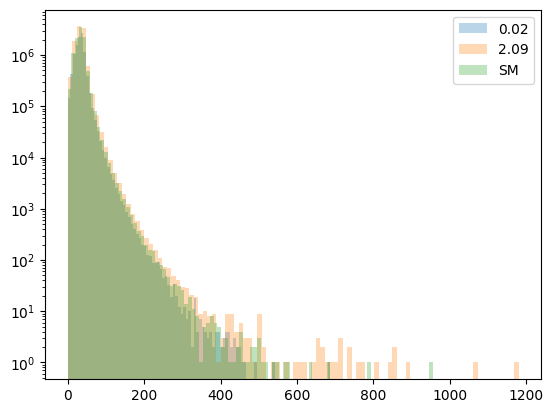

In [18]:
plt.hist(cledq3332_0_02[1], bins=100, alpha=.3, label='0.02')
plt.hist(cledq3332_2_09[1], bins=100, alpha=.3, label='2.09')
plt.hist(SM[1], bins=100, alpha=.3, label='SM')
plt.yscale('log')
plt.legend()
plt.show()

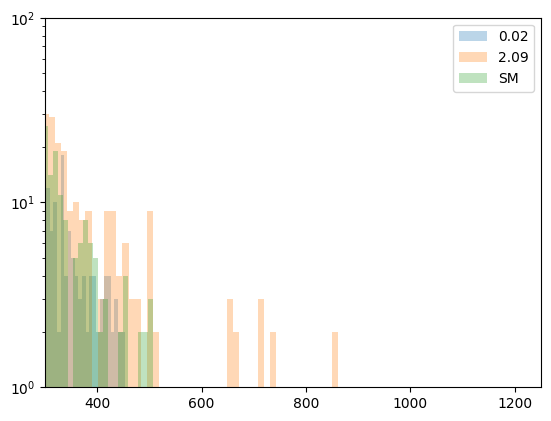

In [19]:
plt.hist(cledq3332_0_02[1], bins=100, alpha=.3, label='0.02')
plt.hist(cledq3332_2_09[1], bins=100, alpha=.3, label='2.09')
plt.hist(SM[1], bins=100, alpha=.3, label='SM')
plt.yscale('log')
plt.xlim(300, 1250)
plt.ylim(1, 100)
plt.legend()
plt.show()

uh oh:

In [20]:
stats.ks_2samp(cledq3332_0_02[1], SM[1])

KstestResult(statistic=np.float64(0.0005870898606968877), pvalue=np.float64(0.061555890466082896), statistic_location=np.float64(32.12611652237251), statistic_sign=np.int8(-1))

In [21]:
stats.ks_2samp(cledq3332_2_09[1], SM[1])

KstestResult(statistic=np.float64(0.0005030204536197735), pvalue=np.float64(0.15524773382176948), statistic_location=np.float64(31.48597103941764), statistic_sign=np.int8(-1))

Notice that the statistic_loaction for both tests is <50GeV. This means we are not compareing NP at the tail of the distrabution, but rather looking at noise in the W+ genneration in the bulk of the distrabution. Sence the KS test finds the point in the CDF with the greatest diffrence, we can assume that the middle of the distrabution is so dominant in scale that its noise overpowers the diffrence in signal expected at the tail. In this case, the KS test is not working.

## Implement and test pT > 150GeV cut

#### Compare the reduction in number of events with pT>150Gev to reduction in cross section using MadGraph's built-in "cut" at the same pT

In [22]:
# extract the subset with pT>150GeV from all three data sets
cledq3332_0_02_150cut = cledq3332_0_02[1][cledq3332_0_02[1] > 150]
cledq3332_2_09_150cut = cledq3332_2_09[1][cledq3332_2_09[1] > 150]
SM_150cut = SM[1][SM[1] > 150]

In [23]:
cledq3332_0_02_ratio = cledq3332_0_02_150cut.size/cledq3332_0_02[1].size
print(cledq3332_0_02_150cut.size, '/', cledq3332_0_02[1].size, '=', cledq3332_0_02_ratio)

4529 / 10097968 = 0.00044850607567779974


In [24]:
cledq3332_2_09_ratio = cledq3332_2_09_150cut.size/cledq3332_2_09[1].size
print(cledq3332_2_09_150cut.size, '/', cledq3332_2_09[1].size, '=', cledq3332_2_09_ratio)

4677 / 10097764 = 0.00046317184675736135


In [25]:
SM_ratio = SM_150cut.size/SM[1].size
print(SM_150cut.size, '/', SM[1].size, '=', SM_ratio)

4459 / 10098109 = 0.0004415678222526614


In [26]:
.23/3670 # done with native cut on 10k event run

6.267029972752044e-05

We have a factor of 10 diffrence between MadGraph's cut and ours, assuming the ratio of cross sections should be the same as the ratio of number of events, which is a promiseing assumption.

Lets update the cross section of the our large data sets using the raitios computed above, then match their luminocity to that which is given in the monotau paper. This should allow us to draw a Gaussian in number-of-event-space for SM and compare that to the two perameter values. 

In [27]:
SM_LHEs = qs.get_LHEs(Path('/home/leo/MadStats/mg5qs/output/cledq__3332_SM'))
cledq3332_0_02_LHEs = qs.get_LHEs(Path('/home/leo/MadStats/mg5qs/output/cledq__3332_0.02'))
cledq3332_2_09_LHEs = qs.get_LHEs(Path('/home/leo/MadStats/mg5qs/output/cledq__3332_2.09'))

In [28]:
crsxSM = qs.weighted_cross_section(SM_LHEs)
crsx3332_0_02 = qs.weighted_cross_section(cledq3332_0_02_LHEs)
crsx3332_2_09 = qs.weighted_cross_section(cledq3332_2_09_LHEs)

In [29]:
print(f"sigma_SM = {crsxSM}")
print(f"sigma_0.02 = {crsx3332_0_02}")
print(f"sigma_2.09 = {crsx3332_2_09}")

sigma_SM = (np.int64(10000000), np.float64(3661.1846221121045), np.float64(0.2745829695534243))
sigma_0.02 = (np.int64(10000000), np.float64(3661.081524494868), np.float64(0.27324477306217154))
sigma_2.09 = (np.int64(10000000), np.float64(3661.2277579791426), np.float64(0.27320108043376345))


$$N = L \sigma$$

In [43]:
# compute new cross section from reduction in event ratio
sigma_3332_0_02 = crsx3332_0_02[1]*cledq3332_0_02_ratio 
# N_ratio<1 indicates we must discard events to reach the given luminocity
N_ratio_3332_0_02 = sigma_3332_0_02*(39e-3) # compute reduction ratio in N to match L
N_3332_0_02 = cledq3332_0_02_150cut[0:int(cledq3332_0_02_150cut.size*N_ratio_3332_0_02)] # reduce N to match L 
N_3332_0_02.size # mean value

290

In [44]:
sigma_3332_2_09 = crsx3332_2_09[1]*cledq3332_2_09_ratio 
N_ratio_3332_2_09 = sigma_3332_2_09*(39e-3) 
N_3332_2_09 = cledq3332_2_09_150cut[0:int(cledq3332_2_09_150cut.size*N_ratio_3332_2_09)] 
N_3332_2_09.size

309

In [45]:
sigma_SM = crsxSM[1]*SM_ratio
N_ratio_SM = sigma_SM*(39e-3) 
N_SM = SM_150cut[0:int(SM_150cut.size*N_ratio_SM)]
N_SM.size 

281

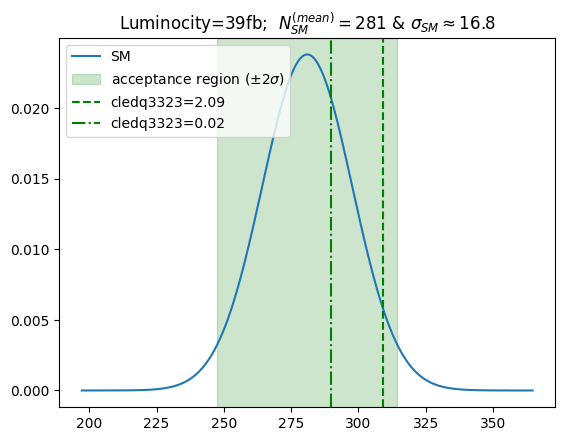

In [46]:
mu = N_SM.size
std = np.sqrt(mu)

gauss = lambda x, mu, sigma: (1/np.sqrt(2*np.pi*(sigma**2))) * np.exp(-((x-mu)**2/(2*(sigma**2))))
x = np.linspace(mu-(std*5), mu+(std*5), 500)
plt.plot(x, gauss(x, mu, std), label='SM')
plt.axvspan(mu+(std*2), mu-(std*2), color='green', alpha=0.2, label='acceptance region $(\\pm 2\\sigma)$')
plt.axvline(N_3332_2_09.size, c='g', ls='--', label='cledq3323=2.09')
plt.axvline(N_3332_0_02.size, c='g', ls='-.', label='cledq3323=0.02')
plt.legend()
plt.title('Luminocity=39fb;  $N_{SM}^{(mean)}=$'+str(mu)+' & $\\sigma_{SM}\\approx$'+str(round(std,1)))
plt.show()

Ok, now say madgraph knows something we don't about implementing cuts, and the factor of 10 difference is not only correct, but also consistant between runs. We can reperduce all above work with $\sigma_{ratio} \rightarrow \frac{\sigma_{ratio}}{10}$.

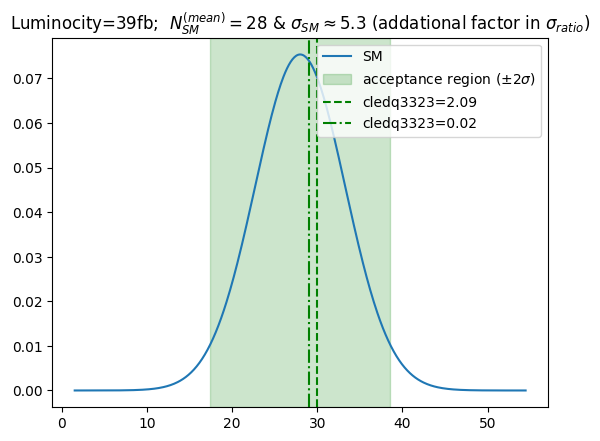

In [42]:
sigma_3332_0_02 = crsx3332_0_02[1]*cledq3332_0_02_ratio/10
N_ratio_3332_0_02 = sigma_3332_0_02*(39e-3)
N_3332_0_02 = cledq3332_0_02_150cut[0:int(cledq3332_0_02_150cut.size*N_ratio_3332_0_02)]

sigma_3332_2_09 = crsx3332_2_09[1]*cledq3332_2_09_ratio /10
N_ratio_3332_2_09 = sigma_3332_2_09*(39e-3)
N_3332_2_09 = cledq3332_2_09_150cut[0:int(cledq3332_2_09_150cut.size*N_ratio_3332_2_09)]

sigma_SM = crsxSM[1]*SM_ratio/10
N_ratio_SM = sigma_SM*(39e-3) 
N_SM = SM_150cut[0:int(SM_150cut.size*N_ratio_SM)]

mu = N_SM.size
std = np.sqrt(mu)

gauss = lambda x, mu, sigma: (1/np.sqrt(2*np.pi*(sigma**2))) * np.exp(-((x-mu)**2/(2*(sigma**2))))
x = np.linspace(mu-(std*5), mu+(std*5), 500)
plt.plot(x, gauss(x, mu, std), label='SM')
plt.axvspan(mu+(std*2), mu-(std*2), color='green', alpha=0.2, label='acceptance region $(\\pm 2\\sigma)$')
plt.axvline(N_3332_2_09.size, c='g', ls='--', label='cledq3323=2.09')
plt.axvline(N_3332_0_02.size, c='g', ls='-.', label='cledq3323=0.02')
plt.legend()
plt.title('Luminocity=39fb;  $N_{SM}^{(mean)}=$'+str(mu)+' & $\\sigma_{SM}\\approx$'+str(round(std,1))+' (addational factor in $\\sigma_{ratio})$')
plt.show()

This appears to make both peram values test closer to the acceptance region, but still one is accepted and the other is not. The mean N is almost exactly 10/prior value, I suppose this makes sence and could have been predicted. Notably, the approxamation to a gaussian is less well supported at O(10^2 events) as opposed to the O(10^3 events) previously, though it should be valid in both cases.